# Exercício 3 — Otimização orientada a Big O com requisitos de desempenho

Aluno: Henrique Goldstein Maluhy Mendes Amaral · DR1_AT · Infnet

Para rodar: Ambiente de execução → Executar tudo.

In [1]:
import math
import random

import matplotlib.pyplot as plt
import pandas as pd

random.seed(42)


class Contador:
    """Guarda as contagens; passo o mesmo objeto para as funções auxiliares."""
    def __init__(self):
        self.comparacoes = 0

## 1. Deduplicação: de O(n²) para O(n)

As duas mantêm a primeira ocorrência de cada valor, na ordem em que apareceu. A lenta procura cada valor na lista de resultados, com busca linear. A rápida guarda o que já viu num conjunto (tabela hash), onde perguntar "já vi?" custa O(1) em média. Na rápida conto uma comparação por consulta ao conjunto.

In [2]:
def deduplicate_slow(arr):
    cont = Contador()
    resultado = []
    for valor in arr:
        repetido = False
        for visto in resultado:          # busca linear no que já guardei
            cont.comparacoes += 1
            if visto == valor:
                repetido = True
                break
        if not repetido:
            resultado.append(valor)
    return resultado, cont.comparacoes


def deduplicate_fast(arr):
    cont = Contador()
    resultado = []
    vistos = set()
    for valor in arr:
        cont.comparacoes += 1            # uma consulta à tabela hash
        if valor not in vistos:
            vistos.add(valor)
            resultado.append(valor)      # a lista garante a ordem de chegada
    return resultado, cont.comparacoes


assert deduplicate_slow([3, 1, 3, 2, 1])[0] == [3, 1, 2]
assert deduplicate_fast([3, 1, 3, 2, 1])[0] == [3, 1, 2]

### Teste de equivalência

300 listas sorteadas. O `dict.fromkeys` aparece só como gabarito do teste.

In [3]:
for _ in range(300):
    n = random.randint(0, 200)
    distintos = random.randint(1, 50)
    arr = [random.randint(1, distintos) for _ in range(n)]
    lento, _ = deduplicate_slow(arr)
    rapido, _ = deduplicate_fast(arr)
    assert lento == rapido == list(dict.fromkeys(arr))
print("300 listas sorteadas: as duas versões devolvem exatamente o mesmo resultado")

300 listas sorteadas: as duas versões devolvem exatamente o mesmo resultado


### Medindo o ganho

A lenta percorre só a lista de resultados, que tem u elementos (os valores distintos). Então ela é O(n·u), e só chega em O(n²) quando quase tudo é distinto. Por isso meço os dois cenários.

In [4]:
linhas = []
for n in [500, 1000, 2000, 4000]:
    for cenario, distintos in [("todos distintos", n), ("5% distintos", n // 20)]:
        arr = random.sample(range(10 * n), n) if distintos == n else \
              [random.randint(1, distintos) for _ in range(n)]
        _, lento = deduplicate_slow(arr)
        _, rapido = deduplicate_fast(arr)
        linhas.append({
            "cenario": cenario, "n": n,
            "lenta": lento, "rapida": rapido,
            "lenta / n²": lento / n**2,
            "rapida / n": rapido / n,
            "ganho (lenta / rapida)": lento / rapido,
        })

dedup = pd.DataFrame(linhas)
dedup

,cenario,n,lenta,rapida,lenta / n²,rapida / n,ganho (lenta / rapida)
0,todos distintos,500,124750,500,0.499000,1.0,249.50000
1,5% distintos,500,6345,500,0.025380,1.0,12.69000
2,todos distintos,1000,499500,1000,0.499500,1.0,499.50000
3,5% distintos,1000,23844,1000,0.023844,1.0,23.84400
4,todos distintos,2000,1999000,2000,0.499750,1.0,999.50000
5,5% distintos,2000,97671,2000,0.024418,1.0,48.83550
6,todos distintos,4000,7998000,4000,0.499875,1.0,1999.50000
7,5% distintos,4000,385137,4000,0.024071,1.0,96.28425


A rápida faz exatamente n comparações (`rapida / n` = 1,0). A lenta com tudo distinto fica em n²/2 (`lenta / n²` perto de 0,5), e o ganho cresce junto com n. Com 5% de valores distintos a lenta fica bem mais barata, porque a lista de resultados é curta.

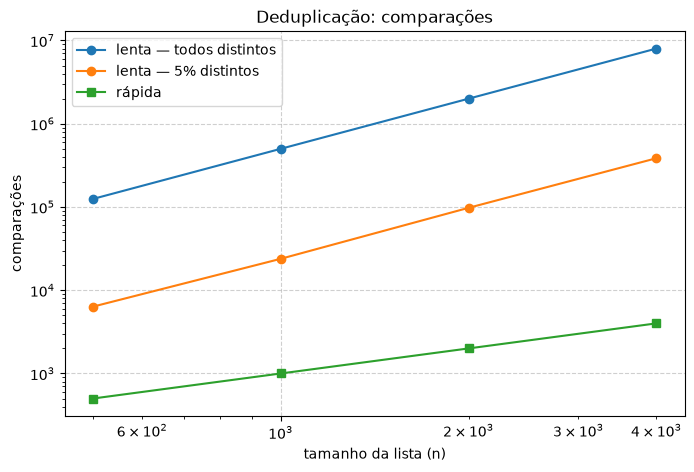

In [5]:
plt.figure(figsize=(8, 5))
for cenario in ["todos distintos", "5% distintos"]:
    parte = dedup[dedup["cenario"] == cenario]
    plt.plot(parte["n"], parte["lenta"], marker="o", label=f"lenta — {cenario}")
parte = dedup[dedup["cenario"] == "todos distintos"]
plt.plot(parte["n"], parte["rapida"], marker="s", label="rápida")
plt.xscale("log")
plt.yscale("log")
plt.title("Deduplicação: comparações")
plt.xlabel("tamanho da lista (n)")
plt.ylabel("comparações")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()

## 2. Os k menores: ordenar tudo × QuickSelect

- Versão A: ordena tudo com merge sort, O(n log n), e pega os k primeiros.
- Versão B: o QuickSelect deixa o k-ésimo menor na posição certa, e tudo à esquerda dele já é menor. Depois ordeno só esses k. O pivô é sorteado, para uma entrada já ordenada não cair no pior caso.

In [6]:
def merge_sort(arr, cont):
    if len(arr) <= 1:
        return arr
    meio = len(arr) // 2
    esquerda = merge_sort(arr[:meio], cont)
    direita = merge_sort(arr[meio:], cont)
    junta = []
    i = j = 0
    while i < len(esquerda) and j < len(direita):
        cont.comparacoes += 1
        if esquerda[i] <= direita[j]:
            junta.append(esquerda[i])
            i += 1
        else:
            junta.append(direita[j])
            j += 1
    return junta + esquerda[i:] + direita[j:]


def particionar(arr, inicio, fim, cont):
    # sorteio o pivô e levo ele para o fim
    p = random.randint(inicio, fim)
    arr[p], arr[fim] = arr[fim], arr[p]
    pivo = arr[fim]
    i = inicio
    for j in range(inicio, fim):
        cont.comparacoes += 1
        if arr[j] < pivo:
            arr[i], arr[j] = arr[j], arr[i]
            i += 1
    arr[i], arr[fim] = arr[fim], arr[i]   # o pivô vai para a posição definitiva
    return i


def quickselect(arr, indice, cont):
    """Deixa em arr[indice] o elemento que estaria ali se arr estivesse ordenado."""
    inicio, fim = 0, len(arr) - 1
    while inicio < fim:
        p = particionar(arr, inicio, fim, cont)
        if p == indice:
            break
        elif indice < p:
            fim = p - 1        # a resposta está à esquerda do pivô
        else:
            inicio = p + 1     # a resposta está à direita
    return arr[indice]


def k_smallest_A(arr, k):
    cont = Contador()
    return merge_sort(arr, cont)[:k], cont.comparacoes


def k_smallest_B(arr, k):
    cont = Contador()
    k = min(k, len(arr))       # pedir mais do que existe devolve tudo
    if k <= 0:
        return [], 0
    copia = arr.copy()
    quickselect(copia, k - 1, cont)
    return merge_sort(copia[:k], cont), cont.comparacoes


def k_smallest(arr, k, versao="B"):
    """A interface pedida no enunciado: escolhe a versão A (ordena tudo) ou B (QuickSelect)."""
    if versao == "A":
        return k_smallest_A(arr, k)
    if versao == "B":
        return k_smallest_B(arr, k)
    raise ValueError(f"versão desconhecida: {versao!r} (use 'A' ou 'B')")


assert k_smallest([9, 4, 7, 1, 8], 3, "A")[0] == k_smallest([9, 4, 7, 1, 8], 3, "B")[0] == [1, 4, 7]

# as duas devolvem a mesma coisa em 200 casos sorteados, incluindo valores repetidos
for _ in range(200):
    n = random.randint(1, 300)
    arr = [random.randint(0, 50) for _ in range(n)]
    k = random.randint(1, n)
    assert k_smallest_A(arr, k)[0] == k_smallest_B(arr, k)[0] == sorted(arr)[:k]
print("200 casos sorteados: A e B devolvem exatamente os mesmos k menores")

200 casos sorteados: A e B devolvem exatamente os mesmos k menores


In [7]:
linhas = []
for n in [1_000, 10_000, 50_000]:
    arr = random.sample(range(10 * n), n)
    for k in [1, 10, 100]:
        _, comp_a = k_smallest_A(arr, k)
        _, comp_b = k_smallest_B(arr, k)
        linhas.append({
            "n": n, "k": k,
            "A_ordena_tudo": comp_a,
            "B_quickselect": comp_b,
            "A / (n·log2 n)": comp_a / (n * math.log2(n)),
            "B / n": comp_b / n,
            "ganho (A / B)": comp_a / comp_b,
        })

ksel = pd.DataFrame(linhas)
ksel

,n,k,A_ordena_tudo,B_quickselect,A / (n·log2 n),B / n,ganho (A / B)
0,1000,1,8698,4784,0.872786,4.78400,1.818144
1,1000,10,8698,1043,0.872786,1.04300,8.339406
2,1000,100,8698,2911,0.872786,2.91100,2.987977
3,10000,1,120403,17137,0.906123,1.71370,7.025909
4,10000,10,120403,16024,0.906123,1.60240,7.513917
5,10000,100,120403,19111,0.906123,1.91110,6.300194
6,50000,1,718427,88659,0.920491,1.77318,8.103261
7,50000,10,718427,53340,0.920491,1.06680,13.468823
8,50000,100,718427,76210,0.920491,1.52420,9.426939


A versão A fica em torno de 0,9·n·log₂ n comparações para qualquer k, porque ordena tudo de qualquer jeito: O(n log n). A versão B fica em poucas comparações por elemento, sem crescer com n: O(n) em média, porque cada partição descarta cerca de metade (n + n/2 + n/4 + ... ≈ 2n), mais O(k log k) para ordenar os k escolhidos. O ganho tende a crescer com n, mas não de forma regular, porque o pivô é sorteado. O pior caso do QuickSelect é O(n²), muito improvável com pivô aleatório.

## 3. A variante em árvore: `k_smallest_bst`

Insiro os valores numa BST e faço uma in-order que para quando junta k valores. O custo é O(h + k): desce até o menor valor (até h passos) e visita mais k nós.

In [8]:
class NoArvore:
    def __init__(self, chave):
        self.chave = chave
        self.esquerda = None
        self.direita = None


def inserir(raiz, chave, cont):
    """Insere de forma iterativa (a árvore degenerada tem altura n) e devolve a raiz."""
    novo = NoArvore(chave)
    if raiz is None:
        return novo
    atual = raiz
    while True:
        cont.comparacoes += 1
        if chave < atual.chave:
            if atual.esquerda is None:
                atual.esquerda = novo
                return raiz
            atual = atual.esquerda
        else:
            if atual.direita is None:
                atual.direita = novo
                return raiz
            atual = atual.direita


def k_smallest_bst(root, k):
    """In-order que para ao juntar k valores. Devolve (valores, nós visitados)."""
    resultado = []
    visitados = 0
    pilha = []
    atual = root
    while (pilha or atual is not None) and len(resultado) < k:
        # desço tudo à esquerda: o menor que falta está lá embaixo
        while atual is not None:
            visitados += 1
            pilha.append(atual)
            atual = atual.esquerda
        atual = pilha.pop()
        resultado.append(atual.chave)
        atual = atual.direita
    return resultado, visitados


def altura(raiz):
    nivel, h = ([raiz] if raiz else []), 0
    while nivel:
        h += 1
        nivel = [f for no in nivel for f in (no.esquerda, no.direita) if f]
    return h


def construir(valores):
    cont = Contador()
    raiz = None
    for v in valores:
        raiz = inserir(raiz, v, cont)
    return raiz, cont.comparacoes


raiz, _ = construir([50, 30, 70, 20, 40, 60, 80])
assert k_smallest_bst(raiz, 3)[0] == [20, 30, 40]
assert k_smallest_bst(raiz, 100)[0] == [20, 30, 40, 50, 60, 70, 80]   # k maior que a árvore
print("k_smallest_bst conferida")

k_smallest_bst conferida


### O pior caso: quando a BST vira uma lista encadeada

Se os valores chegam em ordem, a árvore degenera e fica com altura n. Comparo três formatos com os mesmos 2.000 valores.

In [9]:
n = 2000
valores = list(range(n))
embaralhados = valores.copy()
random.shuffle(embaralhados)
formatos = {
    "aleatória": embaralhados,
    "degenerada (crescente)": valores,
    "degenerada (decrescente)": valores[::-1],
}

linhas = []
for nome, entrada in formatos.items():
    raiz, custo_construcao = construir(entrada)
    h = altura(raiz)
    for k in [1, 10, 100]:
        resposta, visitados = k_smallest_bst(raiz, k)
        assert resposta == list(range(k))
        linhas.append({
            "formato": nome, "altura": h, "construcao_comparacoes": custo_construcao,
            "k": k, "nos_visitados": visitados,
        })

pd.DataFrame(linhas)

,formato,altura,construcao_comparacoes,k,nos_visitados
0,aleatória,24,24291,1,11
1,aleatória,24,24291,10,17
2,aleatória,24,24291,100,103
3,degenerada (crescente),2000,1999000,1,1
4,degenerada (crescente),2000,1999000,10,10
5,degenerada (crescente),2000,1999000,100,100
6,degenerada (decrescente),2000,1999000,1,2000
7,degenerada (decrescente),2000,1999000,10,2000
8,degenerada (decrescente),2000,1999000,100,2000


Construir a árvore degenerada custa n(n-1)/2 comparações, O(n²), contra O(n log n) na aleatória. Na consulta, depende de para que lado ela degenerou: na crescente o menor valor é a raiz e a consulta visita só k nós; na decrescente o menor está no fundo, e mesmo com k = 1 é preciso visitar os 2.000 nós. Então o custo é O(h + k), e para garantir h = O(log n) com qualquer entrada seria preciso uma árvore balanceada, como a AVL.

## 4. Comparação final

- A (ordena tudo): O(n log n) por consulta, qualquer que seja k.
- B (QuickSelect): O(n + k log k) em média; a melhor para uma consulta só.
- BST: construir custa O(n log n) em média e O(n²) no pior caso, mas depois cada consulta custa O(h + k). Compensa quando há muitas consultas sobre os mesmos dados.

## 5. Casos de borda

In [10]:
# listas vazias e com um elemento
assert deduplicate_slow([]) == ([], 0) and deduplicate_fast([]) == ([], 0)
assert deduplicate_fast([5])[0] == [5]

# tudo repetido e tudo distinto
assert deduplicate_fast([7] * 50)[0] == [7]
assert deduplicate_slow(list(range(10)))[0] == list(range(10))

# ordem da primeira ocorrência é mantida, mesmo com tipos diferentes
assert deduplicate_fast(["b", "a", "b", "c", "a"])[0] == ["b", "a", "c"]

# k nos extremos
dados = [9, 4, 7, 1, 8]
assert k_smallest_B(dados, 0)[0] == []
assert k_smallest_B(dados, 1)[0] == [1]
assert k_smallest_B(dados, 5)[0] == [1, 4, 7, 8, 9]
assert k_smallest_A(dados, 5)[0] == [1, 4, 7, 8, 9]
assert k_smallest_B(dados, 10)[0] == k_smallest_A(dados, 10)[0] == [1, 4, 7, 8, 9]   # k > n

# árvore vazia
assert k_smallest_bst(None, 3) == ([], 0)

print("todos os casos de borda passaram")

todos os casos de borda passaram
